# Notebook 01: Data audit, targets and chronological split

## Source
- Dataset: AI in Emergency Medicine - Turkiye (AI-EMT), Kaggle competition data
- URL: https://www.kaggle.com/competitions/ai-emergency-medicine-turkiye/overview
- Downloaded: 2026-10-01
- Synthetic, mechanistically generated data. Not real EHR data.

## Files loaded
| File | Rows | Columns | Size |
|---|---:|---:|---:|
| train.csv | 700,000 | 135 | 433.8 MB |
| supplemental_data.csv | 100,000 | 135 | 62.0 MB |
| hospital_reference.csv | 25 | 15 | <1 MB |
| icd10_reference.csv | 21 | 6 | <1 MB |

test.csv (120.0 MB, no labels) and sample_submission.csv are not used.

## Target definitions
- Kaggle describes both targets only as binary clinical outcomes. No formal definition is given.
- The project plan defines adverse_outcome as ICU admission or in-hospital death. This is unverified.
- Observed: only 49.8% of "Admitted to ICU" and 45.9% of "Died in ED" rows have adverse_outcome = 1. The plan definition does not match the labels.
- Observed: 12.1% of "Died in ED" rows have readmission_30d = 1.
- Decision: targets are used as supplied labels. Their clinical meaning is not claimed.
- Prevalence (train): adverse_outcome 40.8%, readmission_30d 13.7%.

In [1]:
import zipfile
from pathlib import Path

zip_path = Path("../ai-emergency-medicine-turkiye.zip")
out_dir = Path("../data/raw/ai_emt")
out_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path) as z:
    z.extractall(out_dir)

for f in sorted(out_dir.iterdir()):
    print(f.name, round(f.stat().st_size / 1e6, 1), "MB")

hospital_reference.csv 0.0 MB
icd10_reference.csv 0.0 MB
sample_submission.csv 3.8 MB
supplemental_data.csv 62.0 MB
test.csv 120.0 MB
train.csv 433.8 MB


In [2]:
import pandas as pd
from pathlib import Path

raw = Path("../data/raw/ai_emt")
train = pd.read_csv(raw / "train.csv")
supp  = pd.read_csv(raw / "supplemental_data.csv")
hosp  = pd.read_csv(raw / "hospital_reference.csv")
icd   = pd.read_csv(raw / "icd10_reference.csv")

for name, df in [("train", train), ("supp", supp), ("hosp", hosp), ("icd", icd)]:
    print(name, df.shape)

print("Same columns train vs supp:", list(train.columns) == list(supp.columns))
print("Only in train:", set(train.columns) - set(supp.columns))
print("Only in supp:", set(supp.columns) - set(train.columns))

train (700000, 135)
supp (100000, 135)
hosp (25, 15)
icd (21, 6)
Same columns train vs supp: True
Only in train: set()
Only in supp: set()


In [3]:
print(list(train.columns))
print()
print(train.dtypes.value_counts())

['encounter_id', 'arrival_year', 'arrival_month', 'arrival_day', 'arrival_hour', 'arrival_day_of_week', 'arrival_season', 'is_night_shift', 'is_weekend', 'pandemic_period', 'covid_period_flag', 'city', 'nuts2_region', 'latitude', 'longitude', 'urban_rural', 'hospital_type', 'annual_ed_volume', 'bed_count_category', 'age', 'age_group', 'gender', 'is_pediatric', 'is_geriatric', 'height_cm', 'weight_kg', 'bmi', 'insurance_type', 'ses_index', 'arrival_mode', 'triage_level', 'triage_label', 'chief_complaint', 'heart_rate_bpm', 'sbp_mmhg', 'dbp_mmhg', 'map_mmhg', 'pulse_pressure_mmhg', 'respiratory_rate_rpm', 'temperature_celsius', 'spo2_pct', 'gcs_total', 'pain_score_nrs', 'glucose_mgdl', 'creatinine_mgdl', 'bun_mgdl', 'sodium_meql', 'potassium_meql', 'chloride_meql', 'bicarbonate_meql', 'anion_gap_meql', 'wbc_k_ul', 'hemoglobin_gdl', 'hematocrit_pct', 'platelets_k_ul', 'inr', 'aptt_sec', 'lactate_mmoll', 'troponin_i_ngml', 'bnp_pgl', 'crp_mgl', 'procalcitonin_ngl', 'ast_ul', 'alt_ul', 'lip

In [4]:
for t in ["adverse_outcome", "readmission_30d"]:
    print(t, "| dtype:", train[t].dtype)
    print("train:", train[t].value_counts(dropna=False, normalize=True).round(4).to_dict())
    print("supp: ", supp[t].value_counts(dropna=False, normalize=True).round(4).to_dict())
    print()

print("Duplicate IDs in train:", train["encounter_id"].duplicated().sum())
print("Duplicate IDs in supp:", supp["encounter_id"].duplicated().sum())
print("IDs in both train and supp:", len(set(train["encounter_id"]) & set(supp["encounter_id"])))
print("Fully duplicated rows in train (ignoring ID):", train.drop(columns="encounter_id").duplicated().sum())
print()

years = pd.concat(
    [train["arrival_year"].value_counts().sort_index().rename("train"),
     supp["arrival_year"].value_counts().sort_index().rename("supp")],
    axis=1,
)
print(years)

adverse_outcome | dtype: int64
train: {0: 0.592, 1: 0.408}
supp:  {0: 0.592, 1: 0.408}

readmission_30d | dtype: int64
train: {0: 0.8632, 1: 0.1368}
supp:  {0: 0.8624, 1: 0.1376}

Duplicate IDs in train: 0
Duplicate IDs in supp: 0
IDs in both train and supp: 0
Fully duplicated rows in train (ignoring ID): 0

               train   supp
arrival_year               
2019          117165  16651
2020          116831  16655
2021          116448  16615
2022          117047  16806
2023          115923  16519
2024          116586  16754


In [5]:
print(train["disposition"].value_counts(dropna=False))
print()
print(pd.crosstab(train["disposition"], train["adverse_outcome"]))
print()
print(pd.crosstab(train["disposition"], train["readmission_30d"]))
print()
print(train.groupby("arrival_year")[["adverse_outcome", "readmission_30d"]].mean().round(4))

disposition
Discharged Home     326748
Admitted to Ward    205085
Admitted to ICU      78065
Died in ED           41653
Transferred Out      27730
Left AMA             20719
Name: count, dtype: int64

adverse_outcome        0       1
disposition                     
Admitted to ICU    39224   38841
Admitted to Ward  119448   85637
Died in ED         22534   19119
Discharged Home   204411  122337
Left AMA           12399    8320
Transferred Out    16387   11343

readmission_30d        0      1
disposition                    
Admitted to ICU    68664   9401
Admitted to Ward  179244  25841
Died in ED         36613   5040
Discharged Home   277096  49652
Left AMA           18232   2487
Transferred Out    24368   3362

              adverse_outcome  readmission_30d
arrival_year                                  
2019                   0.4077           0.1377
2020                   0.4080           0.1368
2021                   0.4113           0.1377
2022                   0.4089           0.

In [6]:
train["source"] = "train"
supp["source"] = "supp"
df = pd.concat([train, supp], ignore_index=True)

ts_cols = {"arrival_year": "year", "arrival_month": "month",
           "arrival_day": "day", "arrival_hour": "hour"}
df["arrival_ts"] = pd.to_datetime(df[list(ts_cols)].rename(columns=ts_cols), errors="coerce")
print("Unparseable timestamps:", df["arrival_ts"].isna().sum())

def assign_split(year):
    if year <= 2021:
        return "dev"
    if year == 2022:
        return "val"
    return "holdout"

df["split"] = df["arrival_year"].map(assign_split)

sizes = df.groupby("split").agg(
    rows=("encounter_id", "size"),
    first_ts=("arrival_ts", "min"),
    last_ts=("arrival_ts", "max"),
).loc[["dev", "val", "holdout"]]
print(sizes)
print()

# target rates for dev and val only. Holdout labels stay unseen.
print(df[df["split"] != "holdout"]
      .groupby("split")[["adverse_outcome", "readmission_30d"]].mean().round(4))
print()
print(pd.crosstab(df["split"], df["source"]))

Unparseable timestamps: 0
           rows   first_ts             last_ts
split                                         
dev      400365 2019-01-01 2021-12-31 23:00:00
val      133853 2022-01-01 2022-12-31 23:00:00
holdout  265782 2023-01-01 2024-12-30 23:00:00

       adverse_outcome  readmission_30d
split                                  
dev             0.4093           0.1377
val             0.4080           0.1360

source    supp   train
split                 
dev      49921  350444
holdout  33273  232509
val      16806  117047


In [7]:
miss = (df.isna().mean() * 100).round(2)
miss = miss[miss > 0].sort_values(ascending=False)
print("Columns with any missing:", len(miss))
print(miss.to_string())
print()
print(df.groupby("arrival_year")["arrival_ts"].agg(["min", "max"]))

Columns with any missing: 9
consult_specialty    62.02
d_dimer_mgfl         41.98
bnp_pgl              40.02
lipase_ul            38.17
troponin_i_ngml      34.96
procalcitonin_ngl    30.09
albumin_gdl          27.99
lactate_mmoll        24.91
egfr_ml_min          14.98

                    min                 max
arrival_year                               
2019         2019-01-01 2019-12-31 23:00:00
2020         2020-01-01 2020-12-31 23:00:00
2021         2021-01-01 2021-12-31 23:00:00
2022         2022-01-01 2022-12-31 23:00:00
2023         2023-01-01 2023-12-31 23:00:00
2024         2024-01-01 2024-12-30 23:00:00


In [8]:
num = df.select_dtypes("number")
num = num.loc[:, num.nunique() > 2]

summary = pd.DataFrame({
    "min": num.min(),
    "max": num.max(),
    "mean": num.mean().round(2),
    "n_unique": num.nunique(),
    "n_negative": (num < 0).sum(),
})
print(summary.to_string())

                                   min          max       mean  n_unique  n_negative
arrival_year                 2019.0000    2024.0000    2021.50         6           0
arrival_month                   1.0000      12.0000       6.52        12           0
arrival_day                     1.0000      31.0000      15.72        31           0
arrival_hour                    0.0000      23.0000      11.49        24           0
latitude                       36.2021      41.2867      39.21        25           0
longitude                      27.1287      43.4089      32.02        25           0
annual_ed_volume            10000.0000  549717.0000  130080.84    252648           0
age                             0.0000     110.0000      48.08       111           0
height_cm                     130.0000     206.0000     168.13        77           0
weight_kg                      28.0000     154.0000      76.15       125           0
bmi                             7.7000      61.0000      27.03   

In [9]:
# 1. pulse pressure
pp_calc = df["sbp_mmhg"] - df["dbp_mmhg"]
print("Pulse pressure differs from SBP-DBP by >0.5:", ((df["pulse_pressure_mmhg"] - pp_calc).abs() > 0.5).sum())
print("DBP > SBP rows:", (df["dbp_mmhg"] > df["sbp_mmhg"]).sum())
print()

# 2. anion gap
ag_calc = df["sodium_meql"] - df["chloride_meql"] - df["bicarbonate_meql"]
print("Anion gap differs from Na-Cl-HCO3 by >0.2:", ((df["anion_gap_meql"] - ag_calc).abs() > 0.2).sum())
print("Calculated gap < 0:", (ag_calc < 0).sum())
print("Stored gap < 0:", (df["anion_gap_meql"] < 0).sum())
print()

# 3. BMI
bmi_calc = df["weight_kg"] / (df["height_cm"] / 100) ** 2
print("BMI differs from weight/height^2 by >0.1:", ((df["bmi"] - bmi_calc).abs() > 0.1).sum())
print()

# 4. age vs height
young = df[df["age"] < 5]
print("Rows with age < 5:", len(young))
print(young[["age", "height_cm", "weight_kg", "bmi"]].describe().round(1))
print()

# 5. annual_ed_volume
g = df.groupby("city")["annual_ed_volume"].nunique()
print("annual_ed_volume unique per city: min", g.min(), "max", g.max())
g2 = df.groupby(["city", "hospital_type"])["annual_ed_volume"].nunique()
print("unique per city + hospital_type: min", g2.min(), "max", g2.max())

Pulse pressure differs from SBP-DBP by >0.5: 0
DBP > SBP rows: 32

Anion gap differs from Na-Cl-HCO3 by >0.2: 0
Calculated gap < 0: 20329
Stored gap < 0: 20082

BMI differs from weight/height^2 by >0.1: 0

Rows with age < 5: 19344
           age  height_cm  weight_kg      bmi
count  19344.0    19344.0    19344.0  19344.0
mean       0.9      168.2       76.3     27.1
std        1.4        9.2       16.2      5.8
min        0.0      138.0       28.0      9.0
25%        0.0      162.0       65.0     23.1
50%        0.0      168.0       76.0     26.9
75%        2.0      175.0       87.0     30.8
max        4.0      199.0      147.0     52.6

annual_ed_volume unique per city: min 9934 max 134605
unique per city + hospital_type: min 1004 max 55414


In [10]:
drop = ["encounter_id", "source", "split"]
cat_cols = [c for c in df.select_dtypes(include=["object", "string"]).columns if c not in drop]

for c in cat_cols:
    n = df[c].nunique(dropna=False)
    print(f"{c}: {n} unique")
    if n <= 12:
        print(df[c].value_counts(dropna=False).to_dict())
    print()

print("Cities in data, not in hospital_reference:", set(df["city"]) - set(hosp["city"]))
print("Cities in hospital_reference, not in data:", set(hosp["city"]) - set(df["city"]))
print("ICD codes in data, not in icd10_reference:", set(df["primary_icd10_code"]) - set(icd["icd10_code"]))
print("hospital_reference columns:", list(hosp.columns))

arrival_day_of_week: 7 unique
{'Saturday': 114552, 'Monday': 114550, 'Sunday': 114458, 'Tuesday': 114164, 'Friday': 114157, 'Thursday': 114139, 'Wednesday': 113980}

arrival_season: 4 unique
{'Summer': 200946, 'Spring': 200816, 'Autumn': 199961, 'Winter': 198277}

pandemic_period: 4 unique
{'Pre/Post Pandemic': 399598, 'Post-Pandemic': 133853, 'Pandemic Peak': 133486, 'Pandemic Ongoing': 133063}

city: 25 unique

nuts2_region: 7 unique
{'Marmara': 309793, 'Central Anatolia': 125993, 'Mediterranean': 111501, 'Aegean': 105122, 'Southeastern Anatolia': 82297, 'Eastern Anatolia': 36219, 'Black Sea': 29075}

urban_rural: 3 unique
{'Urban': 464126, 'Peri-Urban': 199630, 'Rural': 136244}

hospital_type: 5 unique
{'State Hospital': 318856, 'Training and Research Hospital': 159874, 'Private Hospital': 120431, 'University Hospital': 120391, 'City Hospital': 80448}

bed_count_category: 3 unique
{'Primary (<100k/yr)': 359573, 'Secondary (100-200k/yr)': 333638, 'Tertiary (>200k/yr)': 106789}

age_g

In [11]:
print(pd.crosstab(df["arrival_year"], df["pandemic_period"]))
print()
print(pd.crosstab(df["arrival_year"], df["covid_period_flag"]))

pandemic_period  Pandemic Ongoing  Pandemic Peak  Post-Pandemic  \
arrival_year                                                      
2019                            0              0              0   
2020                            0         133486              0   
2021                       133063              0              0   
2022                            0              0         133853   
2023                            0              0              0   
2024                            0              0              0   

pandemic_period  Pre/Post Pandemic  
arrival_year                        
2019                        133816  
2020                             0  
2021                             0  
2022                             0  
2023                        132442  
2024                        133340  

covid_period_flag       0       1
arrival_year                     
2019               133816       0
2020                    0  133486
2021                    0  133

## Data quality findings
- IDs: no duplicates in train or supp, no overlap between them, no fully duplicated rows.
- train and supp have identical schemas. Merged: 800,000 rows.
- Years 2019 to 2024 all present, about 117k per year in train. No encounters on 2024-12-31.
- Missing values in 9 columns. Seven MNAR labs: d_dimer 41.98%, bnp 40.02%, lipase 38.17%, troponin_i 34.96%, procalcitonin 30.09%, albumin 27.99%, lactate 24.91%. Also egfr_ml_min 14.98% (not listed by Kaggle, cause unknown) and consult_specialty 62.02% (post-presentation, excluded).
- 32 rows with DBP > SBP (negative pulse pressure).
- anion_gap_meql equals Na - Cl - HCO3 exactly. 20,082 rows are negative. It is collinear with its three inputs.
- 19,344 rows with age < 5 have adult-range height and weight. Height, weight and BMI are not age-adjusted.
- annual_ed_volume varies row to row inside one city and hospital type. It is not a fixed hospital attribute.
- pandemic_period and covid_period_flag are exact functions of arrival_year.
- nuts2_region has 7 values (geographic regions), not NUTS-2 regions.
- No hospital ID. Smallest institutional unit: city.
- All 25 cities and 21 ICD codes match the reference tables. hospital_reference repeats nuts2_region, latitude and longitude.
- adverse_outcome prevalence is 40.8%, not rare. readmission_30d is 13.7%.

## Chronological split (train + supp)
| Split | Years | Rows |
|---|---|---:|
| dev | 2019-2021 | 400,365 |
| val | 2022 | 133,853 |
| holdout | 2023-2024 | 265,782 |

In [12]:
reports = Path("../reports/tables")
reports.mkdir(parents=True, exist_ok=True)

status = {}
def mark(cols, label, note=""):
    for c in cols:
        status[c] = (label, note)

mark(["adverse_outcome", "readmission_30d"], "TARGET")
mark(["encounter_id", "source", "split", "arrival_ts"], "BOOKKEEPING", "not a model feature")
mark(["arrival_year", "pandemic_period", "covid_period_flag"], "REGIME_ONLY",
     "exact functions of year; no usable signal for val/holdout")

mark(["arrival_month", "arrival_day", "arrival_hour", "arrival_day_of_week",
      "arrival_season", "is_night_shift", "is_weekend"], "ALLOW", "known at arrival")
mark(["city", "nuts2_region", "latitude", "longitude", "urban_rural",
      "hospital_type", "bed_count_category"], "ALLOW", "static site attribute")
mark(["age", "age_group", "gender", "is_pediatric", "is_geriatric", "height_cm",
      "weight_kg", "bmi", "insurance_type", "ses_index"], "ALLOW", "demographics at arrival")
mark(["arrival_mode", "triage_level", "triage_label", "chief_complaint"], "ALLOW", "triage/presentation")
mark(["heart_rate_bpm", "sbp_mmhg", "dbp_mmhg", "map_mmhg", "pulse_pressure_mmhg",
      "respiratory_rate_rpm", "temperature_celsius", "spo2_pct", "gcs_total",
      "pain_score_nrs"], "ALLOW", "initial vitals")

history = [c for c in df.columns if c.startswith(("comorbidity_", "med_"))]
mark(history + ["charlson_comorbidity_index", "polypharmacy_5plus", "prior_ed_visits_12mo",
                "prior_hospitalization_12mo", "covid_vaccinated"], "ALLOW", "patient history")

labs = ["glucose_mgdl", "creatinine_mgdl", "bun_mgdl", "sodium_meql", "potassium_meql",
        "chloride_meql", "bicarbonate_meql", "anion_gap_meql", "wbc_k_ul", "hemoglobin_gdl",
        "hematocrit_pct", "platelets_k_ul", "inr", "aptt_sec", "lactate_mmoll",
        "troponin_i_ngml", "bnp_pgl", "crp_mgl", "procalcitonin_ngl", "ast_ul", "alt_ul",
        "lipase_ul", "d_dimer_mgfl", "albumin_gdl", "total_bilirubin_mgdl", "calcium_mgdl",
        "phosphorus_mgdl", "magnesium_mgdl", "uric_acid_mgdl", "egfr_ml_min"]
mark(labs, "LAB", "ordered during ED work-up, not at triage; decision pending")

mark(["annual_ed_volume"], "VERIFY", "varies per row inside one hospital type; meaning unknown")
mark(["mews_score", "news2_score"], "VERIFY", "assumed vitals-based; confirm in NB02")
mark(["sofa_score_approx"], "VERIFY", "real SOFA needs labs, ventilation, vasopressors; confirm in NB02")

proc = [c for c in df.columns if c.startswith("proc_")]
mark(proc, "EXCLUDE", "ED intervention, after presentation")
mark(["iv_fluids_ml", "consult_requested", "consult_specialty"], "EXCLUDE", "ED intervention, after presentation")
mark(["triage_to_physician_min", "ed_los_minutes"], "EXCLUDE", "ED process time, after presentation")
mark(["covid_tested", "covid_positive"], "EXCLUDE", "assumed ED-time test and result")
mark(["primary_icd10_code", "primary_diagnosis"], "EXCLUDE", "final diagnosis")
mark(["disposition"], "EXCLUDE", "post-decision; Kaggle says leakage")

print("Unclassified columns:", [c for c in df.columns if c not in status])
print("Names not in df:", [c for c in status if c not in df.columns])
print()

audit = pd.DataFrame([(c, *status[c]) for c in df.columns if c in status],
                     columns=["column", "status", "note"])
audit.to_csv(reports / "leakage_candidates.csv", index=False)

print(audit["status"].value_counts())
print()
for s in ["LAB", "VERIFY", "REGIME_ONLY"]:
    print(s, audit.loc[audit["status"] == s, "column"].tolist())

Unclassified columns: []
Names not in df: []

status
ALLOW          71
LAB            30
EXCLUDE        24
VERIFY          4
BOOKKEEPING     4
REGIME_ONLY     3
TARGET          2
Name: count, dtype: int64

LAB ['glucose_mgdl', 'creatinine_mgdl', 'bun_mgdl', 'sodium_meql', 'potassium_meql', 'chloride_meql', 'bicarbonate_meql', 'anion_gap_meql', 'wbc_k_ul', 'hemoglobin_gdl', 'hematocrit_pct', 'platelets_k_ul', 'inr', 'aptt_sec', 'lactate_mmoll', 'troponin_i_ngml', 'bnp_pgl', 'crp_mgl', 'procalcitonin_ngl', 'ast_ul', 'alt_ul', 'lipase_ul', 'd_dimer_mgfl', 'albumin_gdl', 'total_bilirubin_mgdl', 'calcium_mgdl', 'phosphorus_mgdl', 'magnesium_mgdl', 'uric_acid_mgdl', 'egfr_ml_min']
VERIFY ['annual_ed_volume', 'mews_score', 'sofa_score_approx', 'news2_score']
REGIME_ONLY ['arrival_year', 'pandemic_period', 'covid_period_flag']


## Prediction point and leakage audit

**Prediction point:** end of the initial ED assessment. Allowed: triage, initial vitals, patient history, first-line laboratory work-up. Not allowed: procedures, consults, ED process times, final diagnosis, disposition.

The source documents do not define a prediction timestamp. This definition is a project decision. Laboratory values are ordered after the first physician review, so they are later than triage. A no-labs ablation will measure how much performance depends on them.

| Status | Columns | Meaning |
|---|---:|---|
| ALLOW | 71 | Candidate features |
| LAB | 30 | Candidate features, ordered during work-up. Seven carry informative missingness |
| VERIFY | 4 | annual_ed_volume, mews_score, news2_score, sofa_score_approx. Resolve in Notebook 02 |
| REGIME_ONLY | 3 | arrival_year, pandemic_period, covid_period_flag. Used for regime analysis, not as model inputs |
| EXCLUDE | 24 | Post-presentation: proc_*, iv_fluids_ml, consult_*, triage_to_physician_min, ed_los_minutes, covid_tested, covid_positive, primary_icd10_code, primary_diagnosis, disposition |
| TARGET / BOOKKEEPING | 6 | Not features |

Full list: reports/tables/leakage_candidates.csv

**Reference tables:** hospital_reference joins safely. icd10_reference (typical_los_days, typical_mortality_pct) is keyed on the final diagnosis and is not used as features.

                                 check  result
                           Rows: train  700000
                    Rows: supplemental  100000
                          Rows: merged  800000
                           Raw columns     135
       Duplicate encounter_id (merged)       0
    Fully duplicated rows, ignoring ID       0
                Unparseable timestamps       0
           Columns with missing values       9
                   Rows with DBP > SBP      32
          Rows with negative anion gap   20082
    Rows age < 5 with height >= 130 cm   19344
Cities missing from hospital_reference       0
ICD codes missing from icd10_reference       0


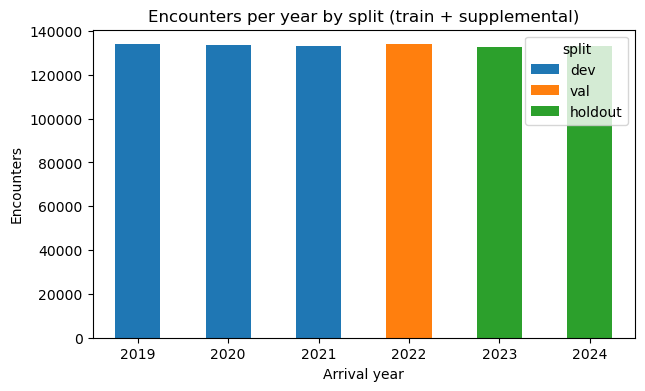

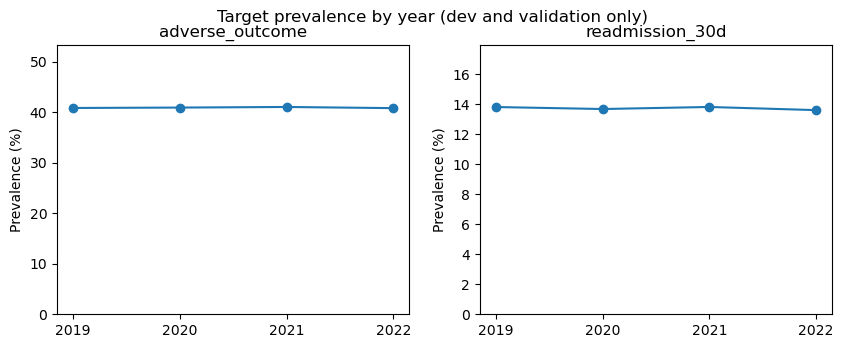

In [13]:
import matplotlib.pyplot as plt

figs = Path("../reports/figures")
figs.mkdir(parents=True, exist_ok=True)

# --- data-quality summary table ---
feature_cols = [c for c in df.columns if c not in ["encounter_id", "source", "split", "arrival_ts"]]
dq = pd.DataFrame([
    ("Rows: train", len(train)),
    ("Rows: supplemental", len(supp)),
    ("Rows: merged", len(df)),
    ("Raw columns", train.shape[1] - 1),
    ("Duplicate encounter_id (merged)", int(df["encounter_id"].duplicated().sum())),
    ("Fully duplicated rows, ignoring ID", int(df[feature_cols].duplicated().sum())),
    ("Unparseable timestamps", int(df["arrival_ts"].isna().sum())),
    ("Columns with missing values", int((df.isna().sum() > 0).sum())),
    ("Rows with DBP > SBP", int((df["dbp_mmhg"] > df["sbp_mmhg"]).sum())),
    ("Rows with negative anion gap", int((df["anion_gap_meql"] < 0).sum())),
    ("Rows age < 5 with height >= 130 cm", int(((df["age"] < 5) & (df["height_cm"] >= 130)).sum())),
    ("Cities missing from hospital_reference", len(set(df["city"]) - set(hosp["city"]))),
    ("ICD codes missing from icd10_reference", len(set(df["primary_icd10_code"]) - set(icd["icd10_code"]))),
], columns=["check", "result"])
dq.to_csv(reports / "data_quality_summary.csv", index=False)
print(dq.to_string(index=False))

# --- figure 1: rows per year by split (no labels used) ---
counts = df.groupby(["arrival_year", "split"]).size().unstack(fill_value=0)[["dev", "val", "holdout"]]
ax = counts.plot(kind="bar", stacked=True, figsize=(7, 4), rot=0)
ax.set_xlabel("Arrival year")
ax.set_ylabel("Encounters")
ax.set_title("Encounters per year by split (train + supplemental)")
plt.savefig(figs / "dataset_composition.png", dpi=150, bbox_inches="tight")
plt.show()

# --- figure 2: target prevalence, dev and val only ---
dv = df[df["split"] != "holdout"]
prev = dv.groupby("arrival_year")[["adverse_outcome", "readmission_30d"]].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for a, t in zip(axes, prev.columns):
    a.plot(prev.index, prev[t], marker="o")
    a.set_title(t)
    a.set_ylabel("Prevalence (%)")
    a.set_xticks(prev.index)
    a.set_ylim(0, prev[t].max() * 1.3)
fig.suptitle("Target prevalence by year (dev and validation only)")
plt.savefig(figs / "outcome_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# --- split summary table (holdout labels left out) ---
split_tbl = df.groupby("split").agg(
    rows=("encounter_id", "size"),
    first_ts=("arrival_ts", "min"),
    last_ts=("arrival_ts", "max"),
    from_train_file=("source", lambda s: int((s == "train").sum())),
    from_supp_file=("source", lambda s: int((s == "supp").sum())),
).loc[["dev", "val", "holdout"]]

prev = df[df["split"] != "holdout"].groupby("split")[["adverse_outcome", "readmission_30d"]].mean().round(4)
split_tbl = split_tbl.join(prev)   # holdout rate stays blank on purpose
split_tbl.to_csv(reports / "split_summary.csv")
print(split_tbl.to_string())
print()

# --- merged data for Notebook 02 (local only, ignored by git) ---
interim = Path("../data/interim")
interim.mkdir(parents=True, exist_ok=True)
df.to_parquet(interim / "merged_with_split.parquet", index=False)
print("Saved:", round((interim / "merged_with_split.parquet").stat().st_size / 1e6, 1), "MB")
print()

print("Figures:", sorted(p.name for p in figs.iterdir()))
print("Tables: ", sorted(p.name for p in reports.iterdir()))

           rows   first_ts             last_ts  from_train_file  from_supp_file  adverse_outcome  readmission_30d
split                                                                                                            
dev      400365 2019-01-01 2021-12-31 23:00:00           350444           49921           0.4093           0.1377
val      133853 2022-01-01 2022-12-31 23:00:00           117047           16806           0.4080           0.1360
holdout  265782 2023-01-01 2024-12-30 23:00:00           232509           33273              NaN              NaN

Saved: 68.6 MB

Figures: ['dataset_composition.png', 'outcome_prevalence.png']
Tables:  ['data_quality_summary.csv', 'leakage_candidates.csv', 'split_summary.csv']


## Key findings
- The planned chronological split works: dev 400,365 / val 133,853 / holdout 265,782 (train + supplemental, split by arrival year).
- adverse_outcome prevalence is 40.8%, not rare. readmission_30d is 13.7%. Both are flat across years in dev and val (adverse_outcome 40.8% to 41.1%, readmission_30d 13.6% to 13.8% in train.csv).
- The labels do not match the project plan's definition of adverse_outcome (ICU admission or death). See "Target definitions" above. Targets are treated as supplied labels.
- arrival_year, pandemic_period and covid_period_flag are exact functions of each other. They cannot generalise to val or holdout, so they are regime-analysis fields only.
- The seven MNAR labs have missing rates of 25% to 42%, matching Kaggle's approximate values.

## Changes to the original plan
- adverse_outcome is not a rare-event target. Its PR-AUC baseline is 0.41. Recall@K and Precision@K thresholds for this target must be chosen accordingly in Notebook 04.
- There is no hospital ID. "Cross-institution" analysis becomes cross-city analysis.
- nuts2_region has 7 geographic regions, not NUTS-2 regions.

## Limitations
- Synthetic data. Nothing here describes real patients or hospitals.
- The clinical meaning of both targets is not verified.
- Validity checks in this notebook used all rows, including holdout features.
- Yearly target prevalence for 2023 and 2024 (train.csv rows) was viewed once during the audit: adverse_outcome 40.7% and 40.5%, readmission_30d 13.6% and 13.6%. No modelling decision used it. Holdout labels are not used again until the final evaluation.
- Holdout ends on 2024-12-30. There are no encounters on 2024-12-31.

## Moves to Notebook 02
- Load data/interim/merged_with_split.parquet.
- Use dev rows only for any EDA that drives a decision.
- Resolve the four VERIFY columns: annual_ed_volume, mews_score, news2_score, sofa_score_approx.
- Decide on negative pulse pressure (32 rows), negative anion gap (20,082 rows) and the age < 5 height and weight values.
- Investigate egfr_ml_min missingness (14.98%).
- Build missingness indicators and the three imputation comparisons.